In [1]:
import pandas as pd
import numpy as np
import joblib

### wczytywanie danych dla modelu Supervised Learning
df = joblib.load('df_with_all_clusters.joblib')

umap_embeddings = np.load('umap_embeddings_10d.npy')

print("Obiekty wczytane.")

### definicja Zmiennych 
#### cechy (features) na których będziemy trenować model
X = umap_embeddings

#### cel (target)
y = df['nmf_topic']

print(f"Kształt danych X (cechy): {X.shape}")

print(f"Kształt danych y (cel): {y.shape}")

Obiekty wczytane.
Kształt danych X (cechy): (850367, 10)
Kształt danych y (cel): (850367,)


In [2]:
from sklearn.model_selection import train_test_split

### podział na zbiór treningowy i testowy ---
###### dane w proporcji 80% na trening, 20% na test
###### random_state=42 - podział będzie zawsze taki sam
###### stratify=y - tutaj ważny parametr -> w zbiorze treningowym i testowym musi być taki sam % udział każdej z 20 klas / tematów
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Rozmiar X_train: {X_train.shape}")
print(f"Rozmiar X_test: {X_test.shape}")

Rozmiar X_train: (680293, 10)
Rozmiar X_test: (170074, 10)


In [3]:
### adding decision boundary visualisation function

from sklearn.decomposition import PCA
from sklearn.base import clone
from numpy import where, arange, meshgrid, hstack, unique
import matplotlib.pyplot as plt

def visualize_decision_boundary_multiclass(X_data, y_data, trained_classifier, title="Granica decyzyjna modelu"):
    """
    Wizualizuje granicę decyzyjną klasyfikatora dla wielu klas 
    po zredukowaniu danych do 2 wymiarów za pomocą PCA.

    Argumenty:
    - X_data: Oryginalne, przetworzone dane (np. X_train_prepared).
    - y_data: Etykiety (np. y_train lub y_test).
    - trained_classifier: Model, którego typ chcemy zwizualizować (np. Random Forest itd.).
    - title: Tytuł wykresu.
    """
    ## redukcja wymiarów danych do 2D
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_data)

    ## klonowanie modelu z jego hiperparametrami aby zachować wszystkie ustawienia (np. n_estimators, max_depth, C, etc.)
    model_2d = clone(trained_classifier)
    model_2d.fit(X_pca, y_data)

    ## tworzenie siatki
    min1, max1 = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    min2, max2 = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    x1grid = arange(min1, max1, 0.1)
    x2grid = arange(min2, max2, 0.1)
    xx, yy = meshgrid(x1grid, x2grid)
    grid = hstack((xx.flatten().reshape(-1,1), yy.flatten().reshape(-1,1)))

    ## predykcja i rysowanie tła
    yhat = model_2d.predict(grid)
    zz = yhat.reshape(xx.shape)
    
    plt.figure(figsize=(16, 16))
    ## ta sama paleta co dla punktów, aby tło pasowało kolorami
    unique_classes = unique(y_data)
    cmap_background = plt.get_cmap('viridis', len(unique_classes))
    plt.contourf(xx, yy, zz, cmap=cmap_background, alpha=0.3)

    ## dynamiczne rysowanie punktów dla wielu klas
    cmap_points = plt.get_cmap('viridis', len(unique_classes))
    for i, class_value in enumerate(unique_classes):
        row_ix = where(y_data == class_value)
        plt.scatter(X_pca[row_ix, 0], X_pca[row_ix, 1],
                    color=cmap_points(i),
                    label=f'Klasa {class_value}',
                    alpha=0.7)

    plt.title(title, fontsize=15)
    plt.xlabel("Główna składowa 1 (PC1)", fontsize=12)
    plt.ylabel("Główna składowa 2 (PC2)", fontsize=12)
    plt.legend()
    plt.show()

In [4]:
### klasa z funkcjami do ewaluacji modeli i kalkulacji / porównania metryk

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, accuracy_score, precision_score, recall_score
import seaborn as sns
from IPython.display import display

class ModelEvaluator:
    """
    Klasa do kompleksowej oceny i wizualizacji modeli klasyfikacyjnych dla problemu wieloklasowego.
    Przechowuje wyniki dla wielu modeli i pozwala na ich porównanie.
    """
    def __init__(self):
        self.results = {}
        self.metrics_summary = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision (weighted)', 
                                                     'Recall (weighted)', 'F1_score (weighted)', 'AUC (weighted)'])

    def evaluate(self, model, model_name, X_train, y_train, X_test, y_test):
        """
        Ocenia już wytrenowany model i generuje raport z metrykami i wizualizacjami.
        """
        print(f"{'='*30}\nOcena modelu: {model_name}\n{'='*30}")

        #### predykcje na zbiorze testowym
        predictions = model.predict(X_test)
        
        #### sprawdzenie czy model ma predict_proba, aby uniknąć błędów
        if hasattr(model, "predict_proba"):
            ##### pobieranie pełnej macierzy prawdopodobieństw (nie tylko dla jednej klasy)
            predictions_proba = model.predict_proba(X_test)
            ##### obliczenie AUC dla wielu klas
            auc = roc_auc_score(y_test, predictions_proba, multi_class='ovr', average='weighted')
        else:
            predictions_proba = None
            auc = np.nan ###### AUC nie jest dostępne

        #### zapis modelu do późniejszej analizy
        self.results[model_name] = {'model': model}
        
        #### METRYKI I WIZUALIZACJE
        print("--- Raport Klasyfikacji ---")
        print(classification_report(y_test, predictions, zero_division=0))
        
        print("\n--- Macierz Omyłek ---")
        cm = confusion_matrix(y_test, predictions)
        plt.figure(figsize=(14, 12))
        ax = sns.heatmap(cm, annot=True, cmap='Blues', fmt='.0f')
        ax.set_title(f'Macierz Omyłek dla: {model_name}\n')
        ax.set_xlabel('\nPredykcja')
        ax.set_ylabel('Rzeczywista wartość')
        plt.show()

        #### obliczenie metryk dla wielu klas (używając uśredniania 'weighted')
        accuracy = accuracy_score(y_test, predictions)
        #### 'weighted' - liczy metryki dla każdej klasy i uśrednia je, ważąc liczbą próbek w każdej klasie
        precision = precision_score(y_test, predictions, average='weighted', zero_division=0)
        recall = recall_score(y_test, predictions, average='weighted', zero_division=0)
        f1 = f1_score(y_test, predictions, average='weighted', zero_division=0)
        
        new_row = pd.DataFrame([{'Model': model_name, 'Accuracy': accuracy, 'Precision (weighted)': precision, 
                                 'Recall (weighted)': recall, 'F1_score (weighted)': f1, 'AUC (weighted)': auc}])
        self.metrics_summary = pd.concat([self.metrics_summary, new_row], ignore_index=True)

        ### WIZUALIZACJA GRANIC DECYZYJNYCH
        print("\n--- Wizualizacje Granic Decyzyjnych ---")

        ## wizualizacja na danych treningowych
        print("\n[Wizualizacja 1/3] Granica decyzyjna na danych treningowych...")
        try:
            visualize_decision_boundary_multiclass(X_train, y_train, model,
                title=f"Granica decyzyjna (dane treningowe) - {model_name}")
        except Exception as e:
            print(f"Nie udało się wygenerować wizualizacji. Błąd: {e}")

        ## wizualizacja na danych testowych z prawdziwymi etykietami
        print("\n[Wizualizacja 2/3] Granica decyzyjna vs. Rzeczywiste klasy (dane testowe)...")
        try:
            visualize_decision_boundary_multiclass(X_test, y_test, model,
                title=f"Granica decyzyjna vs. Rzeczywiste klasy - {model_name}")
        except Exception as e:
            print(f"Nie udało się wygenerować wizualizacji. Błąd: {e}")

        ## wizualizacja na danych testowych z predykcjami
        print("\n[Wizualizacja 3/3] Granica decyzyjna vs. Predykcje (dane testowe)...")
        try:
            # Tworzymy serię z predykcjami, zachowując indeks ze zbioru testowego
            y_pred_series = pd.Series(predictions, index=y_test.index)
            visualize_decision_boundary_multiclass(X_test, y_pred_series, model,
                title=f"Granica decyzyjna vs. Predykcje - {model_name}")
        except Exception as e:
            print(f"Nie udało się wygenerować wizualizacji. Błąd: {e}")

    def display_summary(self, sort_by='F1_score (weighted)'):
        """
        Wyświetla tabelaryczne podsumowanie metryk dla wszystkich ocenionych modeli.
        """
        print(f"\n{'='*30}\nPodsumowanie Metryk Modeli\n{'='*30}")
        if self.metrics_summary.empty:
            print("Brak ocenionych modeli do wyświetlenia.")
        else:
            display(self.metrics_summary.sort_values(by=sort_by, ascending=False).reset_index(drop=True))

In [5]:
### Model Random Forest

import mlflow
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier


evaluator = ModelEvaluator()


## check and set tracking URI
print("Current tracking URI:", mlflow.get_tracking_uri())
mlflow.set_tracking_uri("file:./mlruns")


mlflow.autolog() ### <- właczamy proces autologowania


# rozpoczęcie nowego eksperymentu
mlflow.set_experiment("Covid 19")


# Zakończ aktywny bieg, jeśli istnieje
mlflow.end_run()


## zdefiniowanie modelu
rfc = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')


# siatka hiperparametrów
params_rfc = [
    {
        'n_estimators': [200, 500, 1000],  # Liczba drzew w lesie
        'max_depth': [2, 3, 5, 7, 10],
        'min_samples_leaf': [3, 5, 10],
        'criterion': ['gini', 'entropy'], # Funkcja do oceny jakości podziału
        'min_samples_split': [2, 5, 10], # Minimalna liczba próbek wymagana do podziału węzła
        'max_features': [None, 'sqrt', 'log2'], # Liczba cech branych pod uwagę przy podziale
        'ccp_alpha': [0.0, 0.0001, 0.001],
        'bootstrap': [True, False],  # Czy używać bootstrapowania (losowe próbkowanie z powtórzeniami)
    }
]


## RandomizedSearchCV zamiast GridSearchCV
rfc_randomsearch = RandomizedSearchCV(
    rfc,
    param_distributions=params_rfc,
    n_iter=40,
    scoring='f1_macro',
    cv=5,
    verbose=10,
    n_jobs=-1,
    random_state=42 
)


# Trenowanie modelu na danych treningowych
rfc_randomsearch.fit(X_train, y_train)


# Wyświetlenie najlepszych hiperparametrów
print('\nBest hyperparameters:', rfc_randomsearch.best_params_)


# Zapisanie najlepszego modelu
rfc_model = rfc_randomsearch.best_estimator_

joblib.dump(rfc_model, 'random_forest_best_model.joblib')
print("\nNajlepszy model Random Forest został zapisany.")

Current tracking URI: file:///O:/Projects/covid19/mlruns


2025/09/30 03:35:29 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/09/30 03:35:29 WARNING mlflow.utils.autologging_utils: MLflow statsmodels autologging is known to be compatible with 0.12.2 <= statsmodels <= 0.14.4, but the installed version is 0.14.5. If you encounter errors during autologging, try upgrading / downgrading statsmodels to a compatible version, or try upgrading MLflow.
2025/09/30 03:35:30 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2025/09/30 03:35:30 INFO mlflow.tracking.fluent: Experiment with name 'Covid 19' does not exist. Creating a new experiment.
2025/09/30 03:35:30 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'cf35d73fc0f84d5dae3fb06373cddd63', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2025/09/30 03:35:30 WARNING mlflow.sklearn: Failed to log training dataset information to MLflo

Fitting 5 folds for each of 40 candidates, totalling 200 fits


2025/09/30 10:25:40 INFO mlflow.sklearn.utils: Logging the 5 best runs, 35 runs will be omitted.



Best hyperparameters: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 10, 'criterion': 'entropy', 'ccp_alpha': 0.0, 'bootstrap': True}

Najlepszy model Random Forest został zapisany.


Ocena modelu: Random Forest - best estimator
--- Raport Klasyfikacji ---
              precision    recall  f1-score   support

           0       0.19      0.43      0.26      6531
           1       0.67      0.52      0.59     23719
           2       0.50      0.31      0.38      7000
           3       0.48      0.12      0.19     15234
           4       0.70      0.82      0.75      5970
           5       0.32      0.45      0.37      6203
           6       0.65      0.76      0.70      6303
           7       0.36      0.53      0.43      6919
           8       0.57      0.68      0.62     11550
           9       0.32      0.35      0.33      7371
          10       0.43      0.46      0.45      4445
          11       0.72      0.59      0.64      3687
          12       0.36      0.48      0.41      5182
          13       0.58      0.54      0.56      6346
          14       0.29      0.36      0.32      6769
          15       0.33      0.27      0.30      7238
        

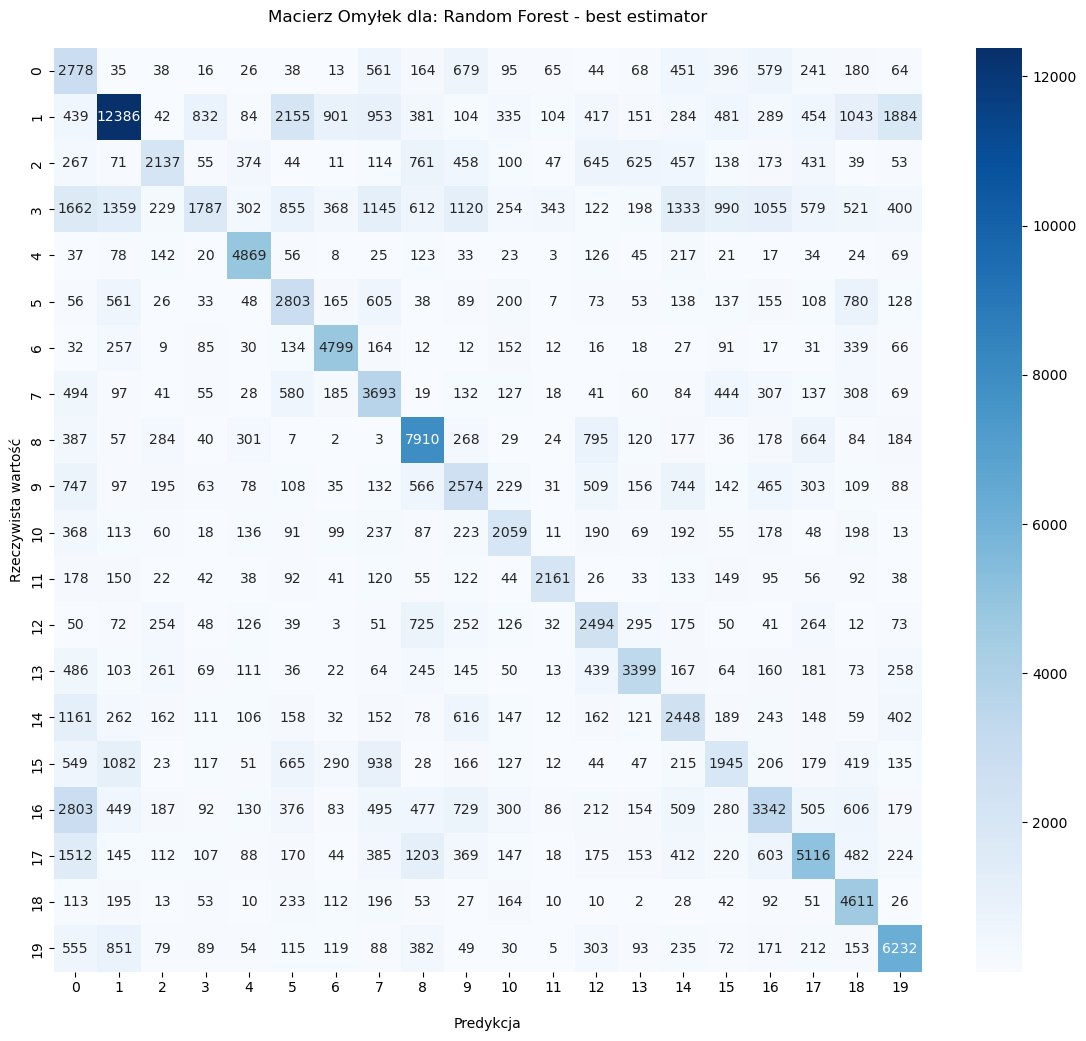

C:\Users\Greg Z\AppData\Local\Temp\ipykernel_2388\1183645679.py:61: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.metrics_summary = pd.concat([self.metrics_summary, new_row], ignore_index=True)
2025/09/30 10:25:44 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '07f402d891cb409dbce0422bb935d93e', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2025/09/30 10:25:45 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2025/09/30 10:25:45 WARNING mlflow.sklearn: Model was mi


--- Wizualizacje Granic Decyzyjnych ---

[Wizualizacja 1/3] Granica decyzyjna na danych treningowych...


2025/09/30 10:25:46 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'bf3b38b2b05d4c33bfa48e018a47af35', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2025/09/30 10:25:46 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'


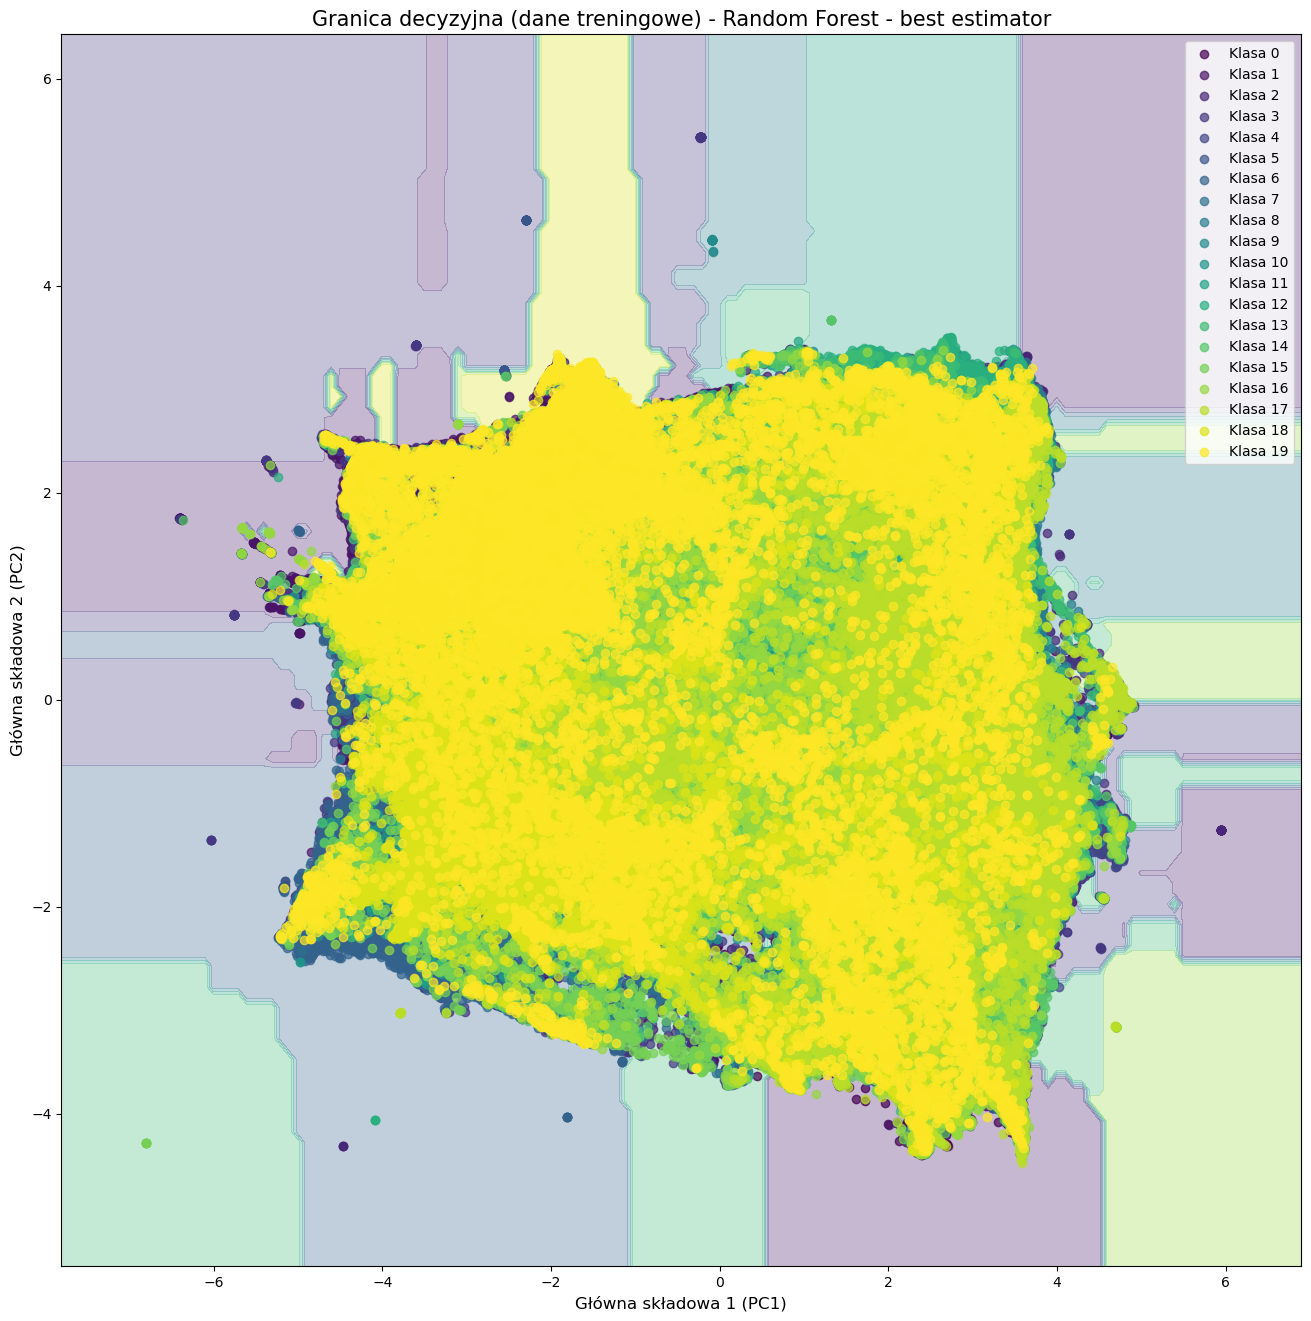

2025/09/30 10:27:20 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'f59b3014a37b4e288fe339e4a73f0215', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2025/09/30 10:27:20 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2025/09/30 10:27:20 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!



[Wizualizacja 2/3] Granica decyzyjna vs. Rzeczywiste klasy (dane testowe)...


2025/09/30 10:27:22 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'ba65a9d3c7d94e1697a27dcef9a472d3', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2025/09/30 10:27:22 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'


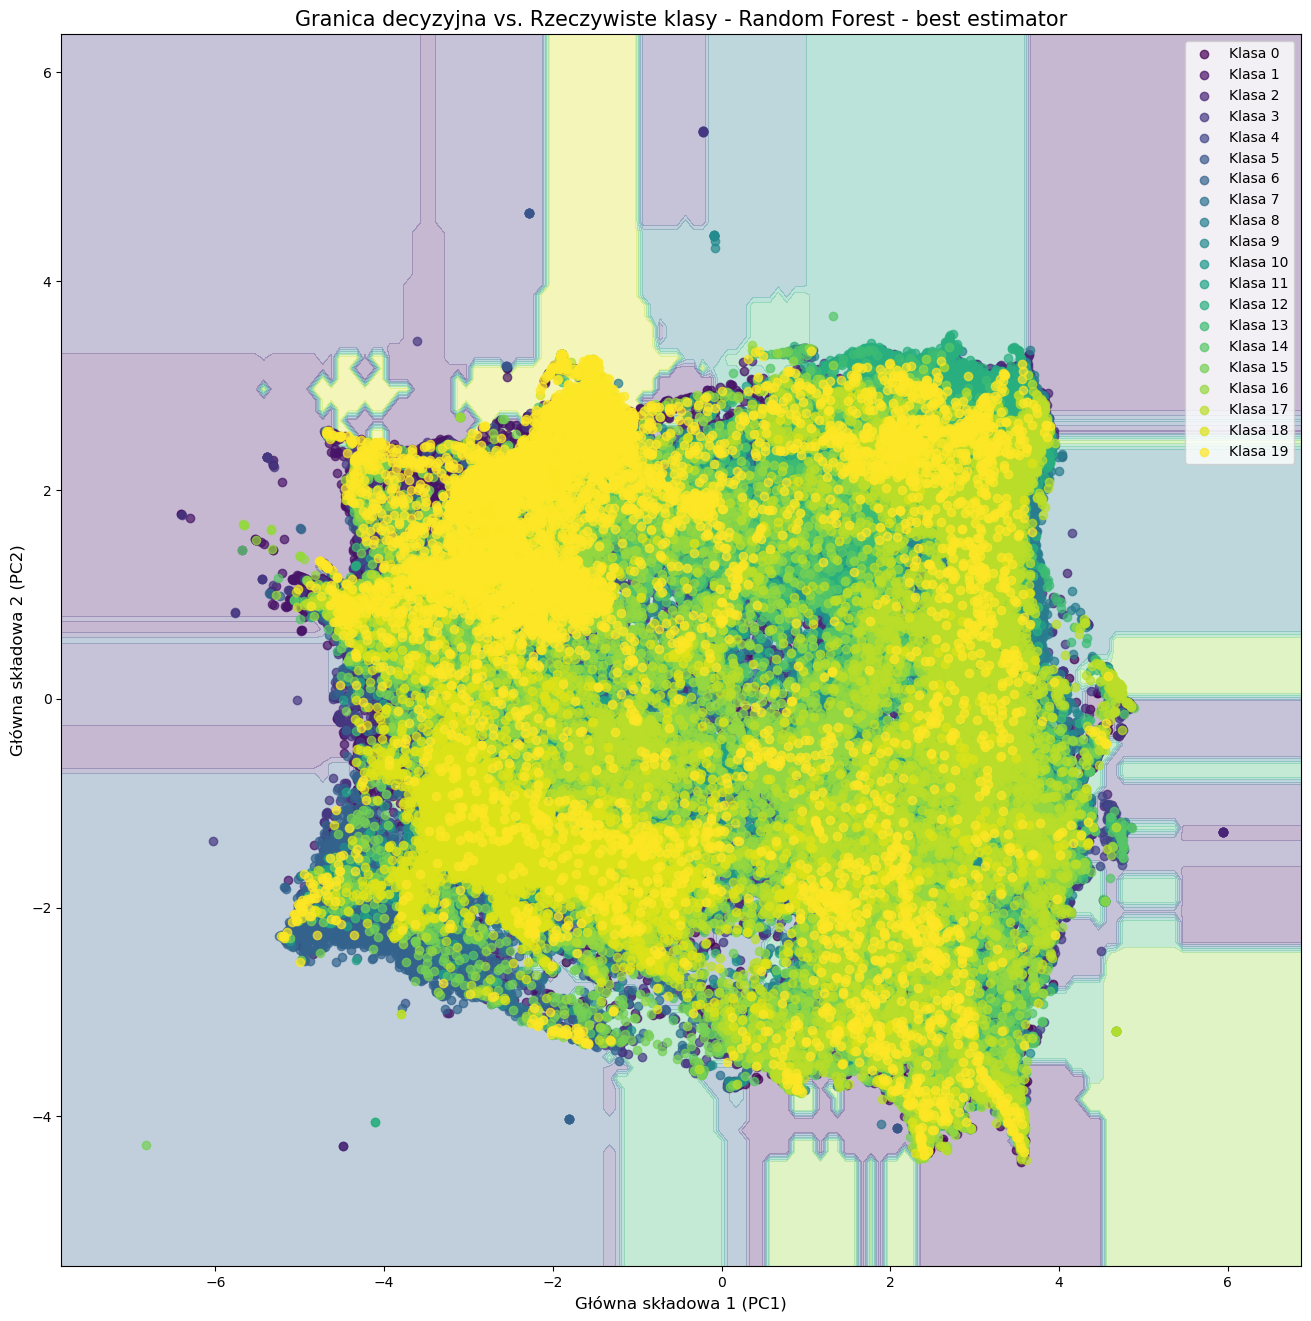

2025/09/30 10:27:45 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'a1c0e5dc1e13487dab366910c8d31eb2', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2025/09/30 10:27:46 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2025/09/30 10:27:46 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!



[Wizualizacja 3/3] Granica decyzyjna vs. Predykcje (dane testowe)...


2025/09/30 10:27:47 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '352445c17ae845349d673586fc60fe2d', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2025/09/30 10:27:47 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'


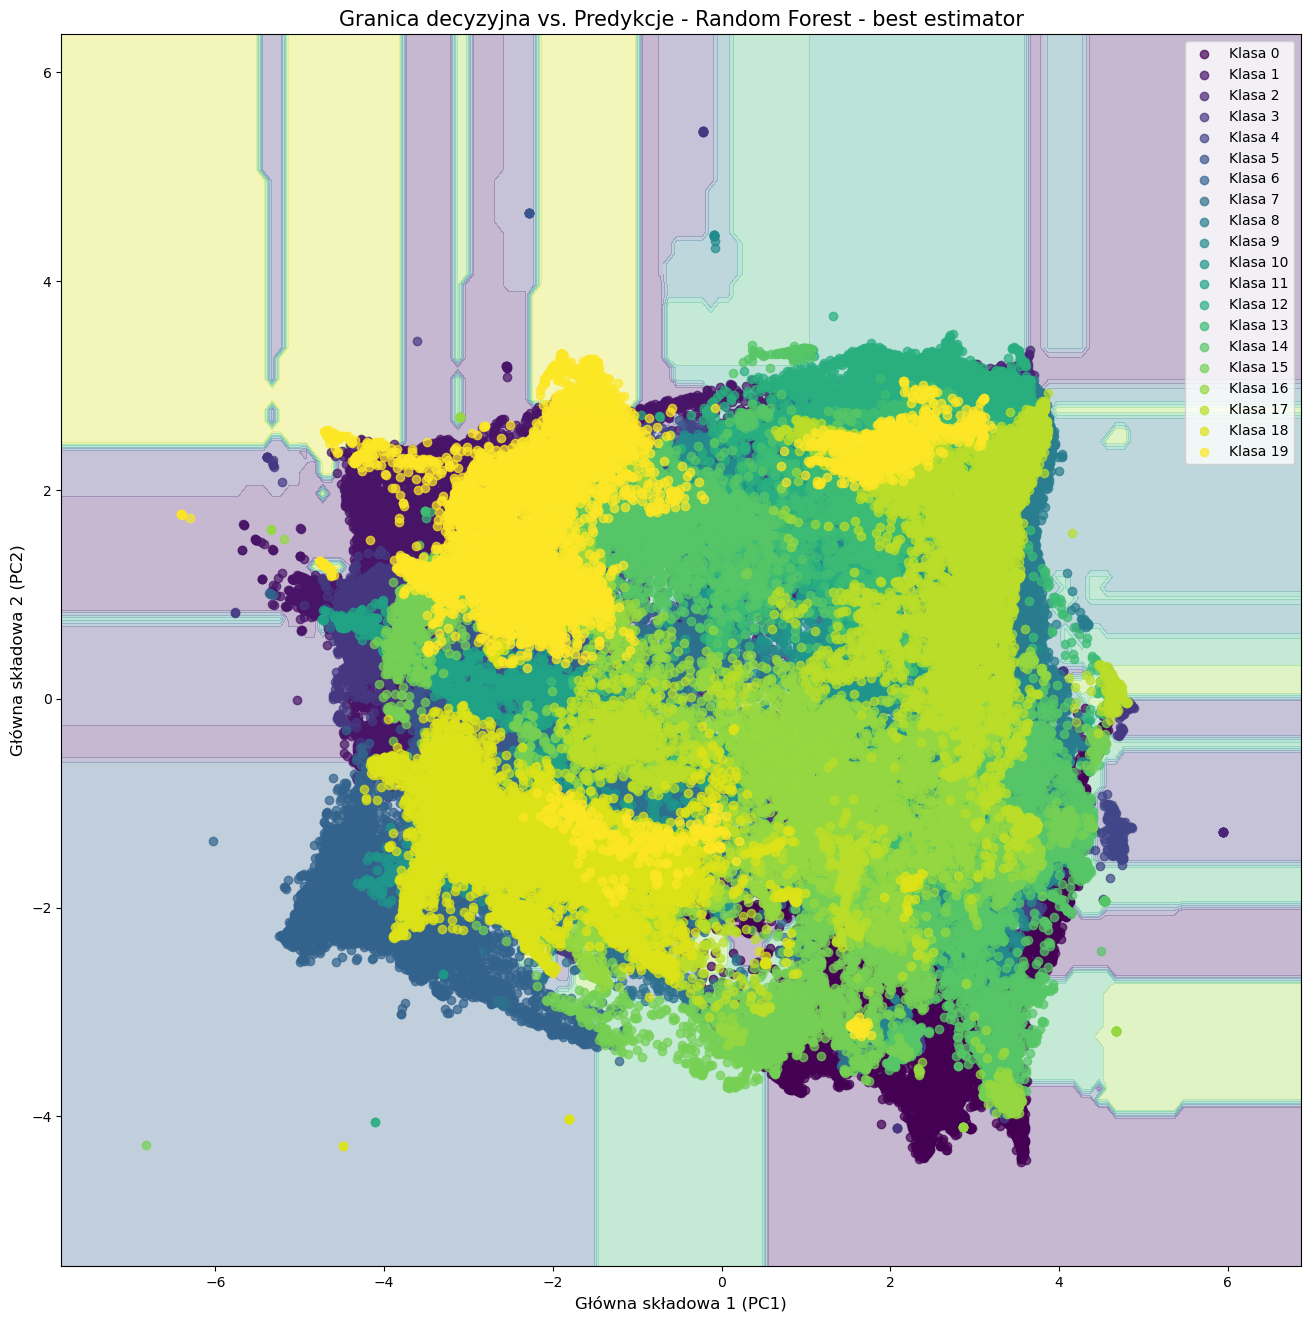


Podsumowanie Metryk Modeli


,Model,Accuracy,Precision (weighted),Recall (weighted),F1_score (weighted),AUC (weighted)
0,Random Forest - best estimator,0.467696,0.491586,0.467696,0.460895,0.897088


In [6]:
## uruchom pełną ocenę modelu
evaluator.evaluate(rfc_model, 'Random Forest - best estimator', X_train, y_train, X_test, y_test)

evaluator.display_summary()

In [17]:
### zapis ewaluatora
joblib.dump(evaluator, 'evaluator.joblib')

print(f"Obiekt ewaluatora został zapisany w pliku evaluator.joblib")

Obiekt ewaluatora został zapisany w pliku evaluator.joblib
